# Spin-Orbit Unmixing using jaxinv (Type 2)

last update: 1/2 (2026) Hajime Kawahara

In this tutorial, we use the Type 2 Bayesian linear inverse problem solver from jaxinv to estimate maps and spectra from multiband time-series data.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

Note: It is known that the current implementation does not work properly unless 64-bit mode is enabled.

In [2]:
from jax import config
config.update("jax_enable_x64", True)


In [ ]:
import numpy as np
import healpy as hp
import matplotlib
from sot.core import sepmat
from sot.core.weight import compute_omega
from sot.core.weight import compute_weight 



In [4]:
fontsize=16
matplotlib.rcParams.update({'font.size':fontsize})
np.random.seed(53)

#set geometry                                                               
inc=45.0/180.0*np.pi
Thetaeq=np.pi
zeta=23.4/180.0*np.pi
Pspin=23.9344699/24.0 #Pspin: a sidereal day                                
wspin=2*np.pi/Pspin
Porb=365.242190402
worb=2*np.pi/Porb                                                          \

Ni=256
obst=np.linspace(0.0,Porb,Ni)

{np.str_('ocean'): np.int64(0), np.str_('desert'): np.int64(100), np.str_('veg'): np.int64(30)}


/home/kawahara/anaconda3/lib/python3.10/site-packages/matplotlib/colorizer.py:191: RuntimeWarning: invalid value encountered in cast
  xx = (xx * 255).astype(np.uint8)


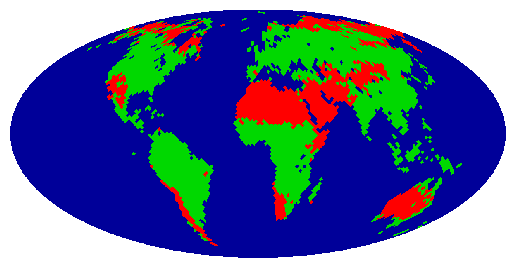

In [5]:
from sot.io.load_data import get_data_filepath
from sot.io.load_data import load_multi_kmap
from sot.plot.plotcmap import mollview_rgb
import matplotlib.pyplot as plt

#multi k map
file_path = get_data_filepath("cmap3class.npz")
cmap, nclass, npix, nside, dict_class = load_multi_kmap(file_path)
Nk = len(dict_class)
print(dict_class)

mollview_rgb(cmap, perm=[2, 1, 0])
hp.graticule(color="white")


In [6]:
from sot.io.load_data import load_refdata

refdict = load_refdata()
reference_surfaces = {"ocean": "water", "desert": "soil", "veg": "vegetation"}
bands = [
    [0.4, 0.45],
    [0.45, 0.5],
    [0.5, 0.55],
    [0.55, 0.6],
    [0.6, 0.65],
    [0.65, 0.7],
    [0.7, 0.75],
    [0.75, 0.8],
    [0.8, 0.85],
    [0.85, 0.9],
]

from sot.core.toymap import generate_multiband_map
map_matrix, spectral_matrix = generate_multiband_map(
    cmap,
    dict_class,
    refdict,
    reference_surfaces,
    bands,
    onsky=True,
    sky=refdict["clear_sky"],
)

Nl = len(bands)

In [ ]:
import jax.numpy as jnp
from jaxinv.model.linear import type2

# geometric weight
Thetav = worb * obst
Phiv = np.mod(wspin * obst, 2 * np.pi)
omega = compute_omega(nside)
WI, WV = compute_weight(zeta, inc, Thetaeq, Thetav, Phiv, omega)
W = jnp.array(WV[:, :] * WI[:, :])
map_matrix = jnp.array(map_matrix)
spectral_matrix = jnp.array(spectral_matrix)

# Light curve
lc = type2(W, spectral_matrix, map_matrix)
noiselevel = 0.001
sigma = noiselevel * np.mean(lc)
noise = sigma * np.random.normal(0.0, 1.0, np.shape(lc))
lc = lc + noise

In [8]:
import jax.numpy as jnp
from jaxinv.bayes.gpkernel import rbf
from jaxinv.bayes.meanmap import meanmap_inverse_type2

tau = 180.0
gamma = 10.0 / 180.0 * np.pi 
separation_matrix = sepmat.calc_sepmatrix(nside)
KS = rbf(separation_matrix, gamma)

#map k-direction covariance
KX = np.eye(Nk)
alpha = 0.25
Pid = jnp.eye(Ni*Nl) * sigma**-2 #when using jnp.eye Matrix becomes singular when x32
Mast = meanmap_inverse_type2(W, spectral_matrix, KS, KX, alpha, Pid, lc)


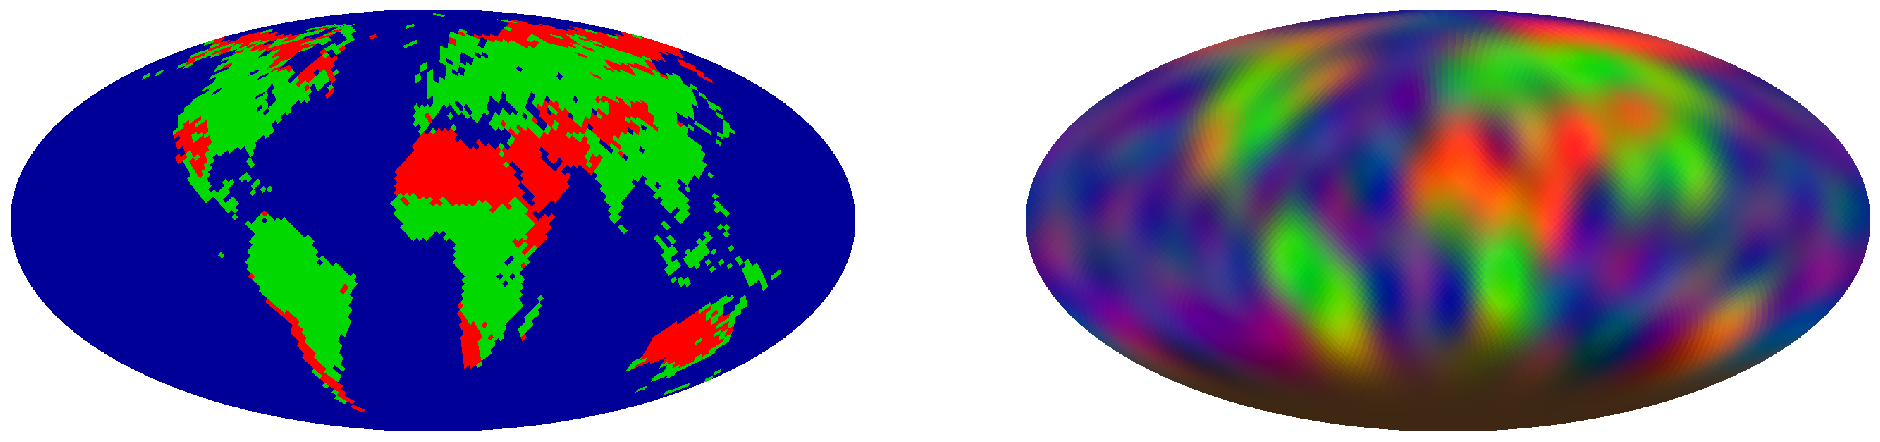

In [10]:
from sot.plot.plotcmap import mollview_rgb

fig = plt.figure(figsize=(24, 6))
ax = fig.add_subplot(1, 2, 2)
mollview_rgb(Mast, ax=ax, perm=[1, 2, 0])
ax = fig.add_subplot(1, 2, 1)
mollview_rgb(cmap, ax=ax, perm=[2, 1, 0])
plt.savefig("type2.png")
plt.show()
